In [23]:
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Validate the Dataset

In [2]:
df = pd.read_csv("../../dataset/fraud/output/synthetic_invoice_dataset.csv")
df.head()

,invoice_number,vendor_id,vendor_name,vendor_category,country,city,po_number,department,invoice_date,due_date,payment_terms,currency,amount,tax_rate,tax_amount,invoice_status,created_timestamp,is_fraud,fraud_type
0,INV-901781-7501,VEND-99FCF6C7,Srivastava LLC,Electronics,India,Hazaribagh,PO-7A1835AA,R&D,2024-11-21,2025-02-19,90,INR,94194.97,0.5091,47954.66,PAID,2024-11-21T20:17:59,1,TAX
1,INV-900858-9865,VEND-34425F7F,"Gera, Baral and Kota",Furniture,India,Bahraich,PO-410C53CE,Procurement,2023-09-07,2023-11-06,60,INR,54163.61,0.1383,7490.83,PAID,2023-09-07T04:05:47,1,PO_MISMATCH
2,INV-002900-847B,VEND-FC45B8AB,Murthy-Sahota Enterprises,Transportation,China,Haridwar,PO-958632C4,Facilities,2023-08-14,2023-11-12,90,CNY,4470.75,0.1047,468.09,OVERDUE,2023-08-14T11:34:16,0,NONE
3,INV-006757-5091,VEND-59049DD4,Kumer-Prasad Pvt Ltd,Transportation,India,Bhalswa Jahangir Pur,PO-317240B0,Facilities,2024-10-21,2024-11-05,15,INR,9705.61,0.0777,754.13,PENDING,2024-10-21T00:05:57,1,DUPLICATE
4,INV-004491-D237,VEND-5235F8EE,"Yohannan, Hegde and Patla",Furniture,USA,Coimbatore,PO-E9735E6D,Procurement,2023-02-20,2023-04-21,60,USD,21885.05,0.1428,3125.19,PENDING,2023-02-20T12:25:55,0,NONE


Total rows = 15,000 ✅

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   invoice_number     15000 non-null  str    
 1   vendor_id          15000 non-null  str    
 2   vendor_name        15000 non-null  str    
 3   vendor_category    15000 non-null  str    
 4   country            15000 non-null  str    
 5   city               15000 non-null  str    
 6   po_number          14760 non-null  str    
 7   department         15000 non-null  str    
 8   invoice_date       15000 non-null  str    
 9   due_date           15000 non-null  str    
 10  payment_terms      15000 non-null  int64  
 11  currency           15000 non-null  str    
 12  amount             15000 non-null  float64
 13  tax_rate           15000 non-null  float64
 14  tax_amount         15000 non-null  float64
 15  invoice_status     15000 non-null  str    
 16  created_timestamp  15000 non-null

In [4]:
df.count()

invoice_number       15000
vendor_id            15000
vendor_name          15000
vendor_category      15000
country              15000
city                 15000
po_number            14760
department           15000
invoice_date         15000
due_date             15000
payment_terms        15000
currency             15000
amount               15000
tax_rate             15000
tax_amount           15000
invoice_status       15000
created_timestamp    15000
is_fraud             15000
fraud_type           15000
dtype: int64

Fraud ratio

In [5]:
print((df["is_fraud"] == 1).sum() / df["is_fraud"].count() * 100)

20.0


In [6]:
pprint(sorted(df["fraud_type"].dropna().unique()))


['AMOUNT_INFLATION',
 'BURST',
 'DUPLICATE',
 'DUPLICATE_PO',
 'NEW_VENDOR',
 'NONE',
 'PO_MISMATCH',
 'ROUNDED',
 'SEQUENTIAL',
 'TAX',
 'WEEKEND']


In [7]:
print(f"Total missing cells: {df.isna().sum().sum()}")
print(f"Total fully duplicate rows: {df.duplicated().sum()}")


Total missing cells: 240
Total fully duplicate rows: 0


In [ ]:
df = df.dropna()

In [9]:
print(f"Total missing cells: {df.isna().sum().sum()}")
print(f"Total fully duplicate rows: {df.duplicated().sum()}")

Total missing cells: 0
Total fully duplicate rows: 0


In [10]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"])
print(f"Start: {df['invoice_date'].min()}")
print(f"End:   {df['invoice_date'].max()}")

Start: 2023-01-01 00:00:00
End:   2024-12-30 00:00:00


In [11]:
# 1. Vendor Distribution (Top 10)
print("--- Top 10 Vendors ---")
print(df["vendor_name"].value_counts().head(10))
print(f"Total Unique Vendors: {df['vendor_name'].nunique()}\n")

--- Top 10 Vendors ---
vendor_name
Pandit Inc LLC                   111
Cheema-Dyal Industries           109
Suri-Cherian                     107
Zachariah, Aurora and Chander    105
Vyas, Chander and Sampath        104
Mohanty-Khatri Enterprises       104
Misra Group                      103
Singh Group Industries           102
Pau, Chana and Rana LLC          101
Subramaniam-Merchant LLC          98
Name: count, dtype: int64
Total Unique Vendors: 497



In [12]:
# 2. Category Distribution
print("--- Vendor Category Distribution ---")
print(df["vendor_category"].value_counts())
print(f"Total Unique Categories: {df['vendor_category'].nunique()}\n")

--- Vendor Category Distribution ---
vendor_category
Office Supplies    3338
Packaging          2491
Transportation     2026
Raw Materials      1666
Maintenance        1616
Electronics         933
IT Services         838
Machinery           689
Consulting          637
Furniture           526
Name: count, dtype: int64
Total Unique Categories: 10



In [13]:
# 3. Amount Distribution Stats
print("--- Invoice Amount Distribution Summary ---")
print(df["amount"].describe())

--- Invoice Amount Distribution Summary ---
count    1.476000e+04
mean     1.022324e+05
std      2.902422e+05
min      1.862610e+03
25%      1.187712e+04
50%      2.564692e+04
75%      7.641768e+04
max      7.076350e+06
Name: amount, dtype: float64


In [14]:
# Shows categories by percentage of total invoices
print("--- Category Distribution (%) ---")
print(df["vendor_category"].value_counts(normalize=True) * 100)


--- Category Distribution (%) ---
vendor_category
Office Supplies    22.615176
Packaging          16.876694
Transportation     13.726287
Raw Materials      11.287263
Maintenance        10.948509
Electronics         6.321138
IT Services         5.677507
Machinery           4.668022
Consulting          4.315718
Furniture           3.563686
Name: proportion, dtype: float64


## Exploratory Data Analysis (EDA)

In [15]:
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import scipy.stats as stats
import missingno as msno
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings

In [16]:
MAIN_COLOR = '#1A73E8' # Google Blue
FRAUD_COLOR = '#D93025' # Google Red
GENUINE_COLOR = '#34A853' # Google Green
BG_COLOR = '#F8F9FA'

In [17]:
date_cols = ['invoice_date', 'due_date', 'created_timestamp']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [18]:
def plot_distribution(data, col, title):
    """Plots interactive distribution with boxplot marginal."""
    fig = px.histogram(
        data, x=col, marginal="box", color='is_fraud',
        color_discrete_map={0: GENUINE_COLOR, 1: FRAUD_COLOR},
        title=f'Distribution of {title}',
        opacity=0.7, barmode='overlay'
    )
    fig.update_layout(template='plotly_white', plot_bgcolor=BG_COLOR)
    fig.show()

def get_outliers(df, col):
    """Returns IQR and Z-score outlier counts."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))].shape[0]
    
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    z_outliers = (z_scores > 3).sum()
    
    return iqr_outliers, z_outliers

def print_section_header(title):
    print("\n" + "="*50)
    print(f" {title} ".center(50, "="))
    print("="*50 + "\n")

In [19]:
# ==========================================
# 1. DATASET OVERVIEW
# ==========================================
print_section_header("1. Dataset Overview")

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

print("Column Data Types:")
print(df.dtypes.value_counts(), "\n")

print("Target Variable (is_fraud) Distribution:")
print(df['is_fraud'].value_counts(normalize=True) * 100)

display(df.head(3))
display(df.describe(include='all').T)


============== 1. Dataset Overview ===============

Dataset Shape: 14760 rows, 19 columns
Memory Usage: 10.08 MB

Column Data Types:
str               11
datetime64[us]     3
float64            3
int64              2
Name: count, dtype: int64 

Target Variable (is_fraud) Distribution:
is_fraud
0    81.300813
1    18.699187
Name: proportion, dtype: float64


,invoice_number,vendor_id,vendor_name,vendor_category,country,city,po_number,department,invoice_date,due_date,payment_terms,currency,amount,tax_rate,tax_amount,invoice_status,created_timestamp,is_fraud,fraud_type
0,INV-901781-7501,VEND-99FCF6C7,Srivastava LLC,Electronics,India,Hazaribagh,PO-7A1835AA,R&D,2024-11-21,2025-02-19,90,INR,94194.97,0.5091,47954.66,PAID,2024-11-21 20:17:59,1,TAX
1,INV-900858-9865,VEND-34425F7F,"Gera, Baral and Kota",Furniture,India,Bahraich,PO-410C53CE,Procurement,2023-09-07,2023-11-06,60,INR,54163.61,0.1383,7490.83,PAID,2023-09-07 04:05:47,1,PO_MISMATCH
2,INV-002900-847B,VEND-FC45B8AB,Murthy-Sahota Enterprises,Transportation,China,Haridwar,PO-958632C4,Facilities,2023-08-14,2023-11-12,90,CNY,4470.75,0.1047,468.09,OVERDUE,2023-08-14 11:34:16,0,NONE


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
invoice_number,14760,14400,INV-006757-5091,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vendor_id,14760,497,VEND-43B1686D,111,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vendor_name,14760,497,Pandit Inc LLC,111,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vendor_category,14760,10,Office Supplies,3338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,14760,6,India,11431,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,14760,255,Raipur,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
po_number,14760,3422,PO-B7CA0FBD,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,14760,10,Operations,1699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
invoice_date,14760,NaN,NaN,NaN,2023-12-30 19:31:13.170731,2023-01-01 00:00:00,2023-06-29 00:00:00,2024-01-01 00:00:00,2024-07-01 00:00:00,2024-12-30 00:00:00,NaN
due_date,14760,NaN,NaN,NaN,2024-02-16 19:54:38.048780,2023-01-16 00:00:00,2023-08-17 00:00:00,2024-02-16 00:00:00,2024-08-18 06:00:00,2025-03-30 00:00:00,NaN


In [20]:
# ==========================================
# 2. DATA QUALITY REPORT
# ==========================================
print_section_header("2. Data Quality Report")


quality_report = {
    "Missing Values": df.isnull().sum()[df.isnull().sum() > 0].to_dict(),
    "Duplicate Rows": df.duplicated().sum(),
    "Duplicate Invoices": df.duplicated(subset=['invoice_number']).sum(),
    "Duplicate POs (Non-null)": df['po_number'].dropna().duplicated().sum(),
    "Invalid Dates (Due < Invoice)": (df['due_date'] < df['invoice_date']).sum(),
    "Negative Amounts": (df['amount'] < 0).sum(),
    "Zero Amounts": (df['amount'] == 0).sum(),
    "Negative Tax": (df['tax_amount'] < 0).sum(),
    "Invalid Payment Terms (< 0)": (df['payment_terms'] < 0).sum()
}

quality_df = pd.DataFrame(list(quality_report.items()), columns=['Check', 'Count'])
display(quality_df)
print("\nInterpretation: Action needed on duplicate invoices and negative amounts before modeling to prevent logic errors.")


============= 2. Data Quality Report =============



,Check,Count
0,Missing Values,{'created_timestamp': 300}
1,Duplicate Rows,0
2,Duplicate Invoices,360
3,Duplicate POs (Non-null),11338
4,Invalid Dates (Due < Invoice),0
5,Negative Amounts,0
6,Zero Amounts,0
7,Negative Tax,0
8,Invalid Payment Terms (< 0),0



Interpretation: Action needed on duplicate invoices and negative amounts before modeling to prevent logic errors.


In [21]:
# ==========================================
# 3. TARGET ANALYSIS
# ==========================================
print_section_header("3. Target Analysis")

fraud_counts = df['is_fraud'].value_counts().reset_index()
fraud_counts.columns = ['is_fraud', 'count']
fraud_counts['is_fraud'] = fraud_counts['is_fraud'].map({0: 'Genuine', 1: 'Fraud'})

fig = px.pie(
    fraud_counts, names='is_fraud', values='count', 
    title='Fraud vs Genuine Ratio',
    color='is_fraud', color_discrete_map={'Genuine': GENUINE_COLOR, 'Fraud': FRAUD_COLOR},
    hole=0.4
)
fig.update_traces(textinfo='percent+label')
fig.show()


=============== 3. Target Analysis ===============



In [24]:
# ==========================================
# 4. NUMERICAL FEATURE ANALYSIS
# ==========================================
print_section_header("4. Numerical Feature Analysis")

num_cols = ['amount', 'tax_rate', 'tax_amount', 'payment_terms']

for col in num_cols:
    # 1. Distribution & Boxplot
    plot_distribution(df, col, col.capitalize())
    
    # 2. Stats
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    iqr_out, z_out = get_outliers(df, col)
    
    print(f"--- {col.upper()} STATS ---")
    print(f"Skewness: {skewness:.2f} | Kurtosis: {kurtosis:.2f}")
    print(f"IQR Outliers: {iqr_out} ({iqr_out/len(df):.1%}) | Z-score Outliers: {z_out} ({z_out/len(df):.1%})\n")

print("Interpretation: High skewness in 'amount' suggests log-transformation might be useful, though XGBoost is scale-invariant. Large outlier overlap between genuine/fraud requires deeper multivariate checks.")


========= 4. Numerical Feature Analysis ==========



--- AMOUNT STATS ---
Skewness: 9.94 | Kurtosis: 134.98
IQR Outliers: 2189 (14.8%) | Z-score Outliers: 168 (1.1%)



--- TAX_RATE STATS ---
Skewness: 3.08 | Kurtosis: 18.47
IQR Outliers: 146 (1.0%) | Z-score Outliers: 146 (1.0%)



--- TAX_AMOUNT STATS ---
Skewness: 10.66 | Kurtosis: 160.65
IQR Outliers: 2173 (14.7%) | Z-score Outliers: 167 (1.1%)



--- PAYMENT_TERMS STATS ---
Skewness: 0.41 | Kurtosis: -0.94
IQR Outliers: 0 (0.0%) | Z-score Outliers: 0 (0.0%)

Interpretation: High skewness in 'amount' suggests log-transformation might be useful, though XGBoost is scale-invariant. Large outlier overlap between genuine/fraud requires deeper multivariate checks.


In [25]:
# ==========================================
# 5. CATEGORICAL ANALYSIS
# ==========================================
print_section_header("5. Categorical Analysis")

cat_cols = ['vendor_category', 'country', 'department', 'currency']

for col in cat_cols:
    counts = df[col].value_counts().reset_index().head(15)
    counts.columns = [col, 'count']
    
    fig = px.bar(
        counts, x=col, y='count', 
        title=f'Top 15 {col.capitalize()}',
        color='count', color_continuous_scale='Blues'
    )
    fig.update_layout(template='plotly_white')
    fig.show()

# Treemap for vendor categories
fig_tree = px.treemap(
    df, path=['department', 'vendor_category'], 
    title='Hierarchy of Department vs Vendor Category',
    color_discrete_sequence=px.colors.qualitative.Prism
)
fig_tree.show()


============ 5. Categorical Analysis =============




============ 6. Time Series Analysis =============



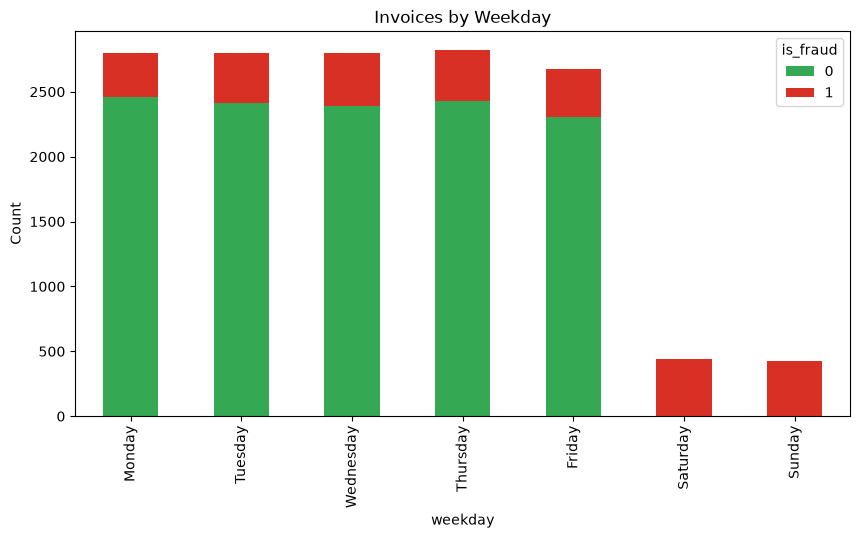

Interpretation: Spikes in weekend activity or off-hours (creation_hour) are strong features for tree-based anomaly detection.


In [26]:
# ==========================================
# 6. TIME SERIES ANALYSIS
# ==========================================
print_section_header("6. Time Series Analysis")

# Feature Engineering for Time
df['invoice_month'] = df['invoice_date'].dt.to_period('M').astype(str)
df['weekday'] = df['invoice_date'].dt.day_name()
df['is_weekend'] = df['invoice_date'].dt.dayofweek >= 5
df['creation_hour'] = df['created_timestamp'].dt.hour

# Trend over time
monthly_trend = df.groupby(['invoice_month', 'is_fraud']).size().reset_index(name='count')
fig = px.line(
    monthly_trend, x='invoice_month', y='count', color='is_fraud',
    title='Invoice Volume Over Time (Fraud vs Genuine)',
    color_discrete_map={0: GENUINE_COLOR, 1: FRAUD_COLOR},
    markers=True
)
fig.show()

# Weekday pattern
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df.groupby(['weekday', 'is_fraud']).size().unstack().reindex(weekday_order)
weekday_counts.plot(kind='bar', stacked=True, color=[GENUINE_COLOR, FRAUD_COLOR], figsize=(10, 5))
plt.title('Invoices by Weekday')
plt.ylabel('Count')
plt.show()

print("Interpretation: Spikes in weekend activity or off-hours (creation_hour) are strong features for tree-based anomaly detection.")

In [27]:
# ==========================================
# 7. VENDOR ANALYSIS
# ==========================================
print_section_header("7. Vendor Analysis")

vendor_stats = df.groupby('vendor_name').agg(
    total_invoices=('invoice_number', 'count'),
    total_spend=('amount', 'sum'),
    avg_invoice=('amount', 'mean'),
    fraud_count=('is_fraud', 'sum')
).reset_index()

vendor_stats['fraud_rate'] = vendor_stats['fraud_count'] / vendor_stats['total_invoices']

# Top Vendors by Volume
top_vendors = vendor_stats.sort_values('total_invoices', ascending=False).head(10)
fig = px.bar(top_vendors, x='vendor_name', y='total_invoices', 
             hover_data=['fraud_rate', 'total_spend'], title='Top 10 Vendors by Invoice Volume')
fig.show()

# Riskiest Vendors (Min 5 invoices to avoid noise)
risky_vendors = vendor_stats[vendor_stats['total_invoices'] >= 5].sort_values('fraud_rate', ascending=False).head(10)
display(risky_vendors)


=============== 7. Vendor Analysis ===============



,vendor_name,total_invoices,total_spend,avg_invoice,fraud_count,fraud_rate
129,"Dey, Brar and Tella",19,6512074.08,3.427407e+05,18,0.947368
245,Lanka-Kari,16,12972942.32,8.108089e+05,15,0.937500
22,"Bala, Chacko and Sangha",12,1522807.21,1.269006e+05,11,0.916667
170,Gour-Bhargava,24,1940069.68,8.083624e+04,22,0.916667
172,Grover-Taneja Enterprises,9,2279748.58,2.533054e+05,8,0.888889
322,Panchal-Upadhyay,16,20365660.86,1.272854e+06,14,0.875000
247,"Loke, Agate and Mandal Enterprises",13,2779027.53,2.137713e+05,11,0.846154
359,Ramaswamy PLC Traders,13,3637115.98,2.797782e+05,11,0.846154
53,Bhakta-Amble,18,4877818.40,2.709899e+05,15,0.833333
234,Krishnamurthy-Koshy Enterprises,6,1207500.11,2.012500e+05,5,0.833333


In [28]:
# ==========================================
# 8. INVOICE ANALYSIS
# ==========================================
print_section_header("8. Invoice Analysis")

# Feature: Invoice Age (Time to pay)
df['days_to_due'] = (df['due_date'] - df['invoice_date']).dt.days

fig = px.histogram(df, x='days_to_due', nbins=50, title='Distribution of Payment Terms (Days to Due)', color='is_fraud', barmode='overlay', color_discrete_map={0: GENUINE_COLOR, 1: FRAUD_COLOR})
fig.show()


============== 8. Invoice Analysis ===============



In [29]:
# ==========================================
# 9. FRAUD PATTERN ANALYSIS (CORE)
# ==========================================
print_section_header("9. Fraud Pattern Analysis")

# Fraud by Category Heatmap
cat_fraud = df.groupby('vendor_category')['is_fraud'].agg(['count', 'mean']).reset_index()
cat_fraud = cat_fraud[cat_fraud['count'] > 50] # filter noise
cat_fraud = cat_fraud.sort_values('mean', ascending=False)

fig = px.bar(cat_fraud, x='vendor_category', y='mean', color='mean',
             title='Fraud Rate by Vendor Category', color_continuous_scale='Reds')
fig.update_layout(yaxis_tickformat='.1%')
fig.show()

# Boxplot: Amount vs Fraud status
fig2 = px.box(df, x='is_fraud', y='amount', color='is_fraud',
              title='Invoice Amount Breakdown: Fraud vs Genuine',
              log_y=True) # Log scale handles extreme outliers visually
fig2.show()

print("Interpretation: Analyzing specific interaction points. Look for categories where fraud rate vastly exceeds the global average.")


=========== 9. Fraud Pattern Analysis ============



Interpretation: Analyzing specific interaction points. Look for categories where fraud rate vastly exceeds the global average.


In [30]:
# ==========================================
# 10. CORRELATION ANALYSIS
# ==========================================
print_section_header("10. Correlation Analysis")

# Spearman is better for non-linear relationships (useful for XGBoost)
corr_cols = num_cols + ['days_to_due', 'is_fraud']
corr_matrix = df[corr_cols].corr(method='spearman')

fig = go.Figure(data=go.Heatmap(
                   z=corr_matrix,
                   x=corr_matrix.columns,
                   y=corr_matrix.columns,
                   colorscale='RdBu_r', zmid=0))
fig.update_layout(title='Spearman Correlation Matrix')
fig.show()

target_corr = corr_matrix['is_fraud'].drop('is_fraud').sort_values()
print("Feature Correlation with Target (Spearman):")
display(target_corr)


============ 10. Correlation Analysis ============



Feature Correlation with Target (Spearman):


payment_terms    0.041826
days_to_due      0.041826
tax_rate         0.193042
tax_amount       0.287152
amount           0.304302
Name: is_fraud, dtype: float64

In [31]:
# ==========================================
# 11. MULTIVARIATE ANALYSIS (PCA)
# ==========================================
print_section_header("11. Multivariate Analysis (PCA)")

# Drop NA for PCA and select numerical
pca_data = df[num_cols].dropna()
labels = df.loc[pca_data.index, 'is_fraud']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

pca = PCA(n_components=2)
components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
pca_df['is_fraud'] = labels.values

fig = px.scatter(pca_df.sample(frac=0.3, random_state=42), x='PC1', y='PC2', color='is_fraud', 
                 opacity=0.6, title='PCA 2D Projection (30% Sample)',
                 color_discrete_map={0: GENUINE_COLOR, 1: FRAUD_COLOR})
fig.show()
print(f"Explained Variance: PC1 {pca.explained_variance_ratio_[0]:.2%}, PC2 {pca.explained_variance_ratio_[1]:.2%}")


======== 11. Multivariate Analysis (PCA) =========



Explained Variance: PC1 51.91%, PC2 25.61%


In [32]:
# ==========================================
# 13. DYNAMIC BUSINESS INSIGHTS
# ==========================================
print_section_header("13. Business Insights Generator")

def generate_insights(df):
    insights = []
    
    # Global metrics
    fraud_rate = df['is_fraud'].mean() * 100
    insights.append(f"Global Fraud Rate sits at {fraud_rate:.2f}%.")
    
    # Vendor Insights
    top_cat = df.groupby('vendor_category')['is_fraud'].mean().idxmax()
    top_cat_val = df.groupby('vendor_category')['is_fraud'].mean().max() * 100
    insights.append(f"Category '{top_cat}' is the most vulnerable, with a fraud rate of {top_cat_val:.2f}%.")
    
    # Amount Insights
    fraud_avg = df[df['is_fraud']==1]['amount'].mean()
    gen_avg = df[df['is_fraud']==0]['amount'].mean()
    multiplier = fraud_avg / gen_avg if gen_avg > 0 else 0
    insights.append(f"Fraudulent invoices are on average {multiplier:.1f}x larger than genuine ones (${fraud_avg:,.2f} vs ${gen_avg:,.2f}).")
    
    # Time Insights
    weekend_fraud = df[df['is_weekend']]['is_fraud'].mean() * 100
    weekday_fraud = df[~df['is_weekend']]['is_fraud'].mean() * 100
    if weekend_fraud > weekday_fraud:
         insights.append(f"Weekends pose higher risk: {weekend_fraud:.1f}% fraud rate vs {weekday_fraud:.1f}% on weekdays.")
         
    # Print dynamically
    for i, ins in enumerate(insights, 1):
        print(f"💡 Insight {i}: {ins}")

generate_insights(df)


======== 13. Business Insights Generator =========

💡 Insight 1: Global Fraud Rate sits at 18.70%.
💡 Insight 2: Category 'Consulting' is the most vulnerable, with a fraud rate of 51.81%.
💡 Insight 3: Fraudulent invoices are on average 4.7x larger than genuine ones ($282,872.88 vs $60,685.14).
💡 Insight 4: Weekends pose higher risk: 100.0% fraud rate vs 13.6% on weekdays.


In [33]:
# ==========================================
# 14. ML READINESS REPORT
# ==========================================
print_section_header("14. ML Readiness Report (XGBoost Prep)")

print("""
✅ Missing Values: Addressed via imputation or native XGBoost handling (XGBoost handles NaNs by assigning them to the optimal split direction).
🚨 Data Leakage Risks: MUST DROP 'fraud_type' and potentially 'invoice_status' (if status is updated AFTER fraud detection).
⚠️ Class Imbalance: High. Recommendation: Use `scale_pos_weight` parameter in XGBoost, or SMOTE/ADASYN during CV.
📊 Outliers: Tree models are robust to outliers, do not clip or drop them. Engineer a boolean flag instead (`is_amount_top_1_percent`).
🔠 Encoding: Target Encoding for high-cardinality features ('vendor_name', 'city'). One-Hot Encoding for low-cardinality ('department', 'currency').
📏 Scaling: NOT REQUIRED for XGBoost. 

🛠️ Feature Engineering Checklist to Build:
1. `amount_vs_vendor_avg`: Ratio of invoice amount to the vendor's historical average.
2. `days_since_vendor_last_invoice`: Time delta to detect sudden invoice bursts.
3. `is_round_amount`: Boolean flag (e.g., amount % 1000 == 0) - common in human-generated fraud.
4. `tax_mismatch_flag`: Boolean (does amount * tax_rate equal tax_amount?).

❌ Columns to Drop Pipeline:
['invoice_number', 'po_number', 'created_timestamp', 'fraud_type']
""")


===== 14. ML Readiness Report (XGBoost Prep) =====


✅ Missing Values: Addressed via imputation or native XGBoost handling (XGBoost handles NaNs by assigning them to the optimal split direction).
🚨 Data Leakage Risks: MUST DROP 'fraud_type' and potentially 'invoice_status' (if status is updated AFTER fraud detection).
⚠️ Class Imbalance: High. Recommendation: Use `scale_pos_weight` parameter in XGBoost, or SMOTE/ADASYN during CV.
📊 Outliers: Tree models are robust to outliers, do not clip or drop them. Engineer a boolean flag instead (`is_amount_top_1_percent`).
🔠 Encoding: Target Encoding for high-cardinality features ('vendor_name', 'city'). One-Hot Encoding for low-cardinality ('department', 'currency').
📏 Scaling: NOT REQUIRED for XGBoost. 

🛠️ Feature Engineering Checklist to Build:
1. `amount_vs_vendor_avg`: Ratio of invoice amount to the vendor's historical average.
2. `days_since_vendor_last_invoice`: Time delta to detect sudden invoice bursts.
3. `is_round_amount`: Boolean fl

## Feature Engineering